In [1]:
# EXPERIMENT NO: 6
# Name: Praveenkumar
# Roll No: 24BAD090

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow Version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow Version: 2.20.0
Libraries imported successfully!


In [2]:
# Load IMDB dataset

num_words = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=num_words
)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))
print("Vocabulary size:", num_words)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
Vocabulary size: 10000


In [3]:
print("First training review:")
print(x_train[0])

print("\nFirst training label:")
print(y_train[0])

print("\nLabel meanings:")
print("0 = Negative")
print("1 = Positive")

First training review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

First training label:
1

Label meani

In [4]:
print("Training dataset class distribution:")
print("Negative reviews:", np.sum(y_train == 0))
print("Positive reviews:", np.sum(y_train == 1))

print("\nTesting dataset class distribution:")
print("Negative reviews:", np.sum(y_test == 0))
print("Positive reviews:", np.sum(y_test == 1))

Training dataset class distribution:
Negative reviews: 12500
Positive reviews: 12500

Testing dataset class distribution:
Negative reviews: 12500
Positive reviews: 12500


In [5]:
# Get the word index
word_index = imdb.get_word_index()

# Reverse the dictionary
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    return " ".join(
        reverse_word_index.get(i - 3, "?")
        for i in encoded_review
    )

print("Sample Review:")
print(decode_review(x_train[0]))

print("\nSentiment:")
print("Positive" if y_train[0] == 1 else "Negative")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Sample Review:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are ama

In [6]:
max_length = 200

In [7]:
# Maximum sequence length
max_length = 200

# Pad training and testing sequences
x_train_padded = pad_sequences(
    x_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

x_test_padded = pad_sequences(
    x_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Original first review length:", len(x_train[0]))
print("Padded first review length:", len(x_train_padded[0]))

print("Training data shape:", x_train_padded.shape)
print("Testing data shape:", x_test_padded.shape)

Original first review length: 218
Padded first review length: 200
Training data shape: (25000, 200)
Testing data shape: (25000, 200)


In [8]:
# Create validation dataset

validation_size = 5000

x_val = x_train_padded[:validation_size]
y_val = y_train[:validation_size]

x_train_final = x_train_padded[validation_size:]
y_train_final = y_train[validation_size:]

print("Training data:", x_train_final.shape)
print("Validation data:", x_val.shape)
print("Testing data:", x_test_padded.shape)

Training data: (20000, 200)
Validation data: (5000, 200)
Testing data: (25000, 200)


PART B — EMBEDDING GENERATION

In [9]:
#Define Embedding Parameters
vocab_size = 10000
embedding_dim = 128

print("Vocabulary size:", vocab_size)
print("Embedding dimension:", embedding_dim)

Vocabulary size: 10000
Embedding dimension: 128


In [10]:
#Create Embedding Layer
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_length
)

print("Embedding layer created successfully!")
print("Embedding output dimension:", embedding_dim)

Embedding layer created successfully!
Embedding output dimension: 128


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [11]:
#Build a Small Embedding Model
embedding_model = Sequential([
    embedding_layer
])

embedding_output = embedding_model.predict(
    x_train_padded[:1],
    verbose=0
)

print("Input shape:", x_train_padded[:1].shape)
print("Embedding output shape:", embedding_output.shape)

Input shape: (1, 200)
Embedding output shape: (1, 200, 128)


PART C — IMPLEMENT LSTM MODEL

In [12]:
#Build the LSTM Model
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    ),

    LSTM(128),

    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
#Compile the Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


PART D — MODEL TRAINING

In [15]:
#Train the LSTM
history = model.fit(
    x_train_final,
    y_train_final,
    epochs=5,
    batch_size=64,
    validation_data=(x_val, y_val)
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 164s 516ms/step - accuracy: 0.5236 - loss: 0.6903 - val_accuracy: 0.5502 - val_loss: 0.6885
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 202s 516ms/step - accuracy: 0.5904 - loss: 0.6626 - val_accuracy: 0.5944 - val_loss: 0.6400
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 209s 538ms/step - accuracy: 0.7368 - loss: 0.5232 - val_accuracy: 0.6168 - val_loss: 0.6322
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 195s 515ms/step - accuracy: 0.7553 - loss: 0.4882 - val_accuracy: 0.7570 - val_loss: 0.5111
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 161s 514ms/step - accuracy: 0.8842 - loss: 0.2877 - val_accuracy: 0.8474 - val_loss: 0.3826


In [16]:
#Record Training and Validation Accuracy
print("Training Accuracy:")
print(history.history['accuracy'])

print("\nValidation Accuracy:")
print(history.history['val_accuracy'])

print("\nTraining Loss:")
print(history.history['loss'])

print("\nValidation Loss:")
print(history.history['val_loss'])

Training Accuracy:
[0.5235999822616577, 0.5904499888420105, 0.7367500066757202, 0.7553499937057495, 0.8841999769210815]

Validation Accuracy:
[0.5501999855041504, 0.5943999886512756, 0.6168000102043152, 0.7570000290870667, 0.8474000096321106]

Training Loss:
[0.6903488039970398, 0.6626400947570801, 0.5232107639312744, 0.48817768692970276, 0.2876527011394501]

Validation Loss:
[0.68845134973526, 0.6399619579315186, 0.6321712732315063, 0.5110753774642944, 0.382567822933197]


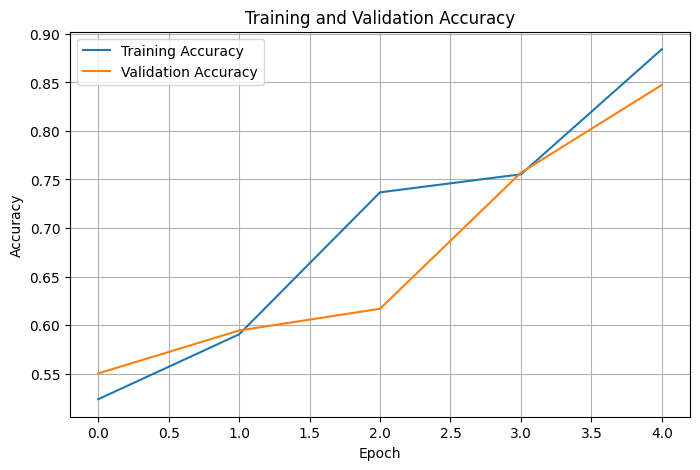

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid()

plt.show()

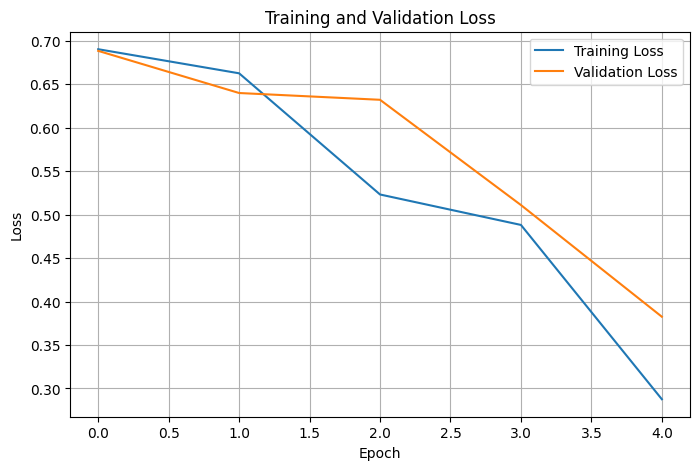

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid()

plt.show()

In [19]:
test_loss, test_accuracy = model.evaluate(
    x_test_padded,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 104ms/step - accuracy: 0.8341 - loss: 0.3946
Test Loss: 0.39457422494888306
Test Accuracy: 0.834119975566864


In [20]:
y_probability = model.predict(
    x_test_padded,
    verbose=0
)

y_pred = (y_probability >= 0.5).astype(int).flatten()

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!
First 20 predictions:
[0 1 1 0 1 1 1 0 1 1 1 0 0 0 1 0 1 1 0 0]


In [21]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluation Metrics")
print("------------------")
print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1-Score  :", f1)

Evaluation Metrics
------------------
Accuracy  : 0.83412
Precision : 0.8295069033530572
Recall    : 0.84112
F1-Score  : 0.8352730883813306


Confusion Matrix:
[[10339  2161]
 [ 1986 10514]]


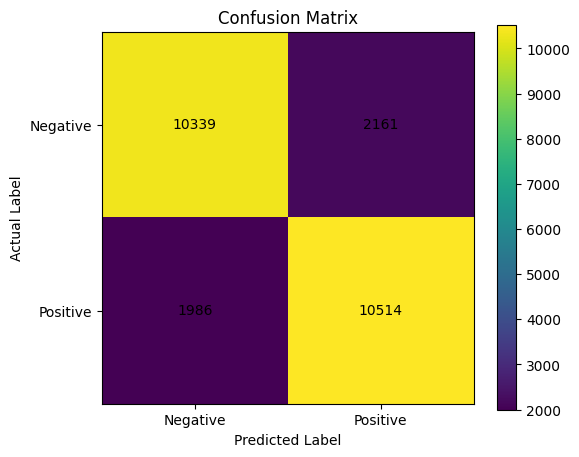

In [22]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

In [23]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Positive']
))

              precision    recall  f1-score   support

    Negative       0.84      0.83      0.83     12500
    Positive       0.83      0.84      0.84     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



In [24]:
def predict_sentiment(review):
    sequence = imdb.get_word_index()

    words = review.lower().split()

    encoded = []

    for word in words:
        encoded.append(sequence.get(word, 2) + 3)

    padded = pad_sequences(
        [encoded],
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    probability = model.predict(padded, verbose=0)[0][0]

    if probability >= 0.5:
        return "Positive", probability
    else:
        return "Negative", probability

In [25]:
review1 = "This movie was excellent and I really enjoyed it."

review2 = "This movie was boring and I hated it."

print("Review 1:", review1)
print("Prediction:", predict_sentiment(review1))

print("\nReview 2:", review2)
print("Prediction:", predict_sentiment(review2))

Review 1: This movie was excellent and I really enjoyed it.
Prediction: ('Positive', np.float32(0.97158927))

Review 2: This movie was boring and I hated it.
Prediction: ('Negative', np.float32(0.26311564))
